In [14]:
import torch
import torch.nn as nn 
import torch.optim as optim 
import numpy as np 
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader, TensorDataset

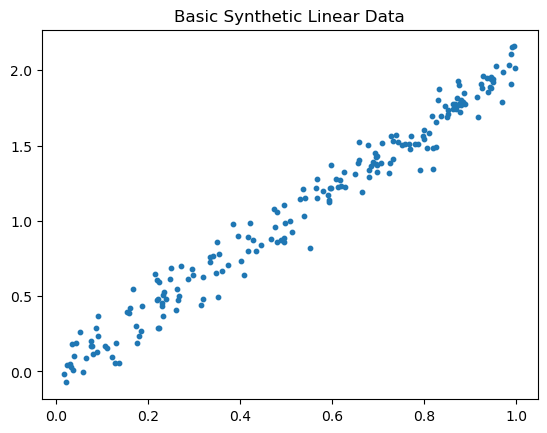

In [15]:
x = np.random.rand(200)
y = 2 * x + np.random.normal(0, 0.1, 200)

plt.scatter(x, y, s=10)
plt.title("Basic Synthetic Linear Data")
plt.show()

In [16]:
data = np.stack((x, y), axis=1)
data = torch.tensor(data, dtype=torch.float32)

batch_size = 10
dataset_loader = DataLoader(
    TensorDataset(data),
    batch_size=batch_size,
    shuffle=True
)

In [17]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [18]:
def vae_loss(recon_x, x, mu, logvar):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_div = -0.01 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


In [19]:
input_dim = 2
latent_dim = 1

vae = VAE(input_dim, latent_dim)
optimizer = optim.Adam(vae.parameters(), lr=0.001)

num_epochs = 1000

for epoch in range(num_epochs):
    vae.train()
    total_loss = 0

    for batch in dataset_loader:
        batch_data = batch[0]

        optimizer.zero_grad()
        recon, mu, logvar = vae(batch_data)
        loss = vae_loss(recon, batch_data, mu, logvar)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(dataset_loader):.4f}")


Epoch [100/1000], Loss: 0.0417
Epoch [200/1000], Loss: 0.0413
Epoch [300/1000], Loss: 0.0409
Epoch [400/1000], Loss: 0.0402
Epoch [500/1000], Loss: 0.0407
Epoch [600/1000], Loss: 0.0395
Epoch [700/1000], Loss: 0.0408
Epoch [800/1000], Loss: 0.0423
Epoch [900/1000], Loss: 0.0425
Epoch [1000/1000], Loss: 0.0405


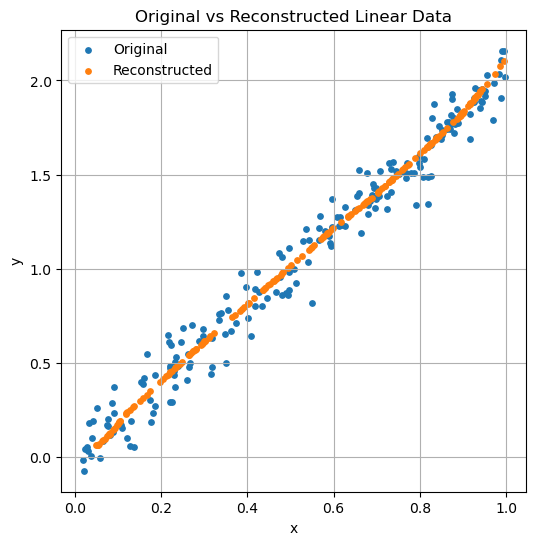

In [20]:
vae.eval()
reconstructed_data = []

with torch.no_grad():
    for batch in dataset_loader:
        recon, _, _ = vae(batch[0])
        reconstructed_data.append(recon)

reconstructed_data = torch.cat(reconstructed_data).numpy()
data_np = data.numpy()

plt.figure(figsize=(6,6))
plt.scatter(data_np[:,0], data_np[:,1], label="Original", s=15)
plt.scatter(reconstructed_data[:,0], reconstructed_data[:,1],
            label="Reconstructed", s=15)
plt.legend()
plt.title("Original vs Reconstructed Linear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


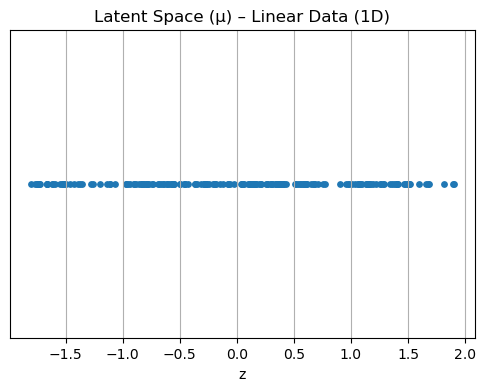

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(latent_mu[:,0], np.zeros_like(latent_mu[:,0]), s=15)
plt.title("Latent Space (μ) – Linear Data (1D)")
plt.xlabel("z")
plt.yticks([])
plt.grid(True)
plt.show()
